# 2025-06-20. Markov random field analysis

## Summary

The goal of this notebook is to enable the detection of interactions using a Markov-Random Field methodology.


## Preparing data

We first need to create a dataframe that includes as rows each of the interactions, and as columns each of the species.

In [43]:
import pandas as pd
import seaborn as sns 

In [44]:
motus_df = pd.read_csv("../results/2025-06-13.sprint/base.motus-hits.csv", sep=';')
motus_df

,taxonomy,taxid,gtdb_genome_representative,abundance,library,Site_code,Collection_code,Location,Longitude,Latitude,Host_taxon,Habitat,No_extracts,phylum,class,family,order,genus,species
0,Mycoplasma genitalium,2097,NaN,1.0,PV001,M1,M1V,Aranjuez,-3.345220,40.03184,Amaranthus sp,Crop,8.0,Mycoplasmatota,NaN,Mycoplasmoidaceae,Mycoplasmoidales,Mycoplasmoides,Mycoplasmoides genitalium
1,uncultured Clostridium sp.,59620,GB GCA 900548855.1,9.0,PV002,M1,M1V,Aranjuez,-3.345220,40.03184,Convolvulus arvensis,Crop,11.0,Bacillota,Clostridia,Clostridiaceae,Eubacteriales,Clostridium,uncultured Clostridium sp.
2,Mycoplasma genitalium,2097,NaN,1.0,PV002,M1,M1V,Aranjuez,-3.345220,40.03184,Convolvulus arvensis,Crop,11.0,Mycoplasmatota,NaN,Mycoplasmoidaceae,Mycoplasmoidales,Mycoplasmoides,Mycoplasmoides genitalium
3,Candidatus Phytoplasma solani,69896,RS GCF 000970375.1,6.0,PV002,M1,M1V,Aranjuez,-3.345220,40.03184,Convolvulus arvensis,Crop,11.0,Mycoplasmatota,Mollicutes,Acholeplasmataceae,Acholeplasmatales,Candidatus Phytoplasma,Candidatus Phytoplasma solani
4,Neisseria sp. oral taxon 014,641148,RS GCF 005886145.1,3.0,PV003,M1,M1V,Aranjuez,-3.345220,40.03184,Cucumis melo,Crop,13.0,Pseudomonadota,Betaproteobacteria,Neisseriaceae,Neisseriales,Neisseria,Neisseria sp. oral taxon 014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1484,Pseudomonas syringae,317,RS GCF 023278085.1,1.0,PV587,H1,H1P,Villaconejos,-3.477574,40.04933,Hirschfeldia incana,Crop,8.0,Pseudomonadota,Gammaproteobacteria,Pseudomonadaceae,Pseudomonadales,Pseudomonas,Pseudomonas syringae
1485,Paenibacillus sp. TI45-13ar,1886670,RS GCF 001721045.1,1.0,PV587,H1,H1P,Villaconejos,-3.477574,40.04933,Hirschfeldia incana,Crop,8.0,Bacillota,Bacilli,Paenibacillaceae,Bacillales,Paenibacillus,Paenibacillus nuruki
1486,uncultured Clostridium sp.,59620,GB GCA 900548855.1,9.0,PV588,H1,H1P,Villaconejos,-3.477574,40.04933,Hordeum vulgare,Crop,8.0,Bacillota,Clostridia,Clostridiaceae,Eubacteriales,Clostridium,uncultured Clostridium sp.
1487,Rothia mucilaginosa [Rothia sp. HMSC071B01/Rot...,43675,RS GCF 000175615.1,1.0,PV588,H1,H1P,Villaconejos,-3.477574,40.04933,Hordeum vulgare,Crop,8.0,Actinomycetota,Actinomycetes,Micrococcaceae,Micrococcales,Rothia,Rothia mucilaginosa


In [45]:
motus_df.drop_duplicates(['library', 'taxid'], keep='first')

,taxonomy,taxid,gtdb_genome_representative,abundance,library,Site_code,Collection_code,Location,Longitude,Latitude,Host_taxon,Habitat,No_extracts,phylum,class,family,order,genus,species
0,Mycoplasma genitalium,2097,NaN,1.0,PV001,M1,M1V,Aranjuez,-3.345220,40.03184,Amaranthus sp,Crop,8.0,Mycoplasmatota,NaN,Mycoplasmoidaceae,Mycoplasmoidales,Mycoplasmoides,Mycoplasmoides genitalium
1,uncultured Clostridium sp.,59620,GB GCA 900548855.1,9.0,PV002,M1,M1V,Aranjuez,-3.345220,40.03184,Convolvulus arvensis,Crop,11.0,Bacillota,Clostridia,Clostridiaceae,Eubacteriales,Clostridium,uncultured Clostridium sp.
2,Mycoplasma genitalium,2097,NaN,1.0,PV002,M1,M1V,Aranjuez,-3.345220,40.03184,Convolvulus arvensis,Crop,11.0,Mycoplasmatota,NaN,Mycoplasmoidaceae,Mycoplasmoidales,Mycoplasmoides,Mycoplasmoides genitalium
3,Candidatus Phytoplasma solani,69896,RS GCF 000970375.1,6.0,PV002,M1,M1V,Aranjuez,-3.345220,40.03184,Convolvulus arvensis,Crop,11.0,Mycoplasmatota,Mollicutes,Acholeplasmataceae,Acholeplasmatales,Candidatus Phytoplasma,Candidatus Phytoplasma solani
4,Neisseria sp. oral taxon 014,641148,RS GCF 005886145.1,3.0,PV003,M1,M1V,Aranjuez,-3.345220,40.03184,Cucumis melo,Crop,13.0,Pseudomonadota,Betaproteobacteria,Neisseriaceae,Neisseriales,Neisseria,Neisseria sp. oral taxon 014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1484,Pseudomonas syringae,317,RS GCF 023278085.1,1.0,PV587,H1,H1P,Villaconejos,-3.477574,40.04933,Hirschfeldia incana,Crop,8.0,Pseudomonadota,Gammaproteobacteria,Pseudomonadaceae,Pseudomonadales,Pseudomonas,Pseudomonas syringae
1485,Paenibacillus sp. TI45-13ar,1886670,RS GCF 001721045.1,1.0,PV587,H1,H1P,Villaconejos,-3.477574,40.04933,Hirschfeldia incana,Crop,8.0,Bacillota,Bacilli,Paenibacillaceae,Bacillales,Paenibacillus,Paenibacillus nuruki
1486,uncultured Clostridium sp.,59620,GB GCA 900548855.1,9.0,PV588,H1,H1P,Villaconejos,-3.477574,40.04933,Hordeum vulgare,Crop,8.0,Bacillota,Clostridia,Clostridiaceae,Eubacteriales,Clostridium,uncultured Clostridium sp.
1487,Rothia mucilaginosa [Rothia sp. HMSC071B01/Rot...,43675,RS GCF 000175615.1,1.0,PV588,H1,H1P,Villaconejos,-3.477574,40.04933,Hordeum vulgare,Crop,8.0,Actinomycetota,Actinomycetes,Micrococcaceae,Micrococcales,Rothia,Rothia mucilaginosa


In [46]:
motus_df['foo'] = 1
motus_df_pvt = motus_df.drop_duplicates(['library', 'taxid'], keep='first').pivot(index='library', columns='taxid', values='foo').fillna(0).astype(int)

<Axes: xlabel='taxid', ylabel='library'>

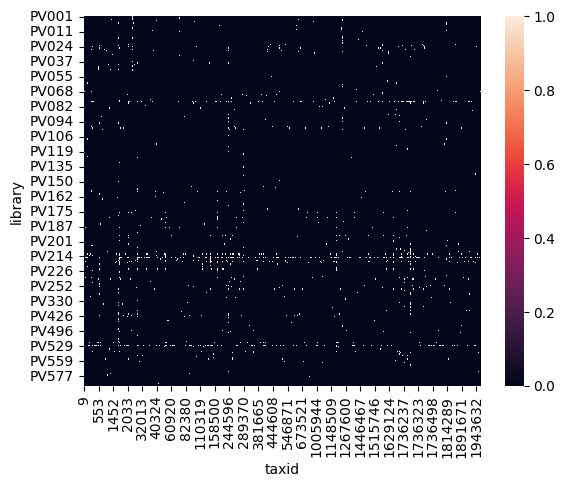

In [47]:
sns.heatmap(motus_df_pvt)

In [48]:
motus_df_pvt.to_csv("../results/2025-06-13.sprint/intdata.bacteria-species-pivot.csv", sep=';')

I fear that this won't be very practical, because as we can see in the plot above, the plot is extremely sparse. Let's bin.

In [49]:
ranks = ['phylum', 'class', 'family', 'order', 'genus', 'species']
motus_pvt_collection = dict()
for r in ranks:
    motus_pvt_collection[r] = motus_df.drop_duplicates(['library', r], keep='first').pivot(index='library', columns=r, values='foo').fillna(0).astype(int)


<Axes: xlabel='genus', ylabel='library'>

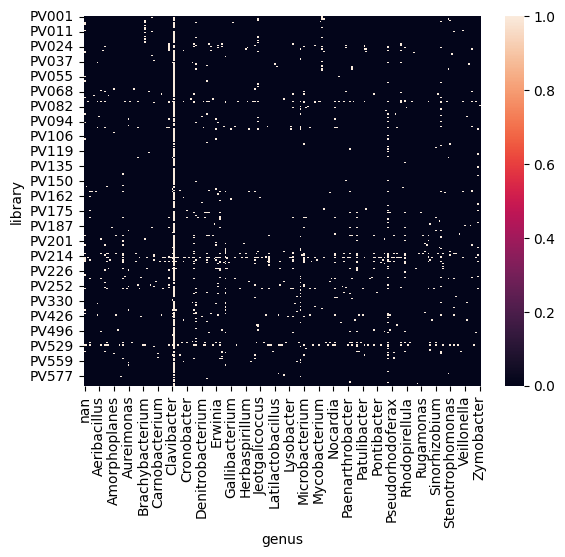

In [50]:
sns.heatmap(motus_pvt_collection['genus'])

<Axes: xlabel='order', ylabel='library'>

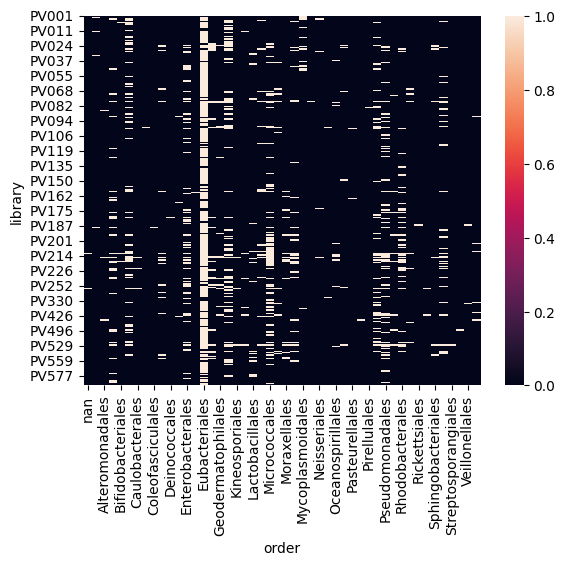

In [51]:
sns.heatmap(motus_pvt_collection['order'])

<Axes: xlabel='family', ylabel='library'>

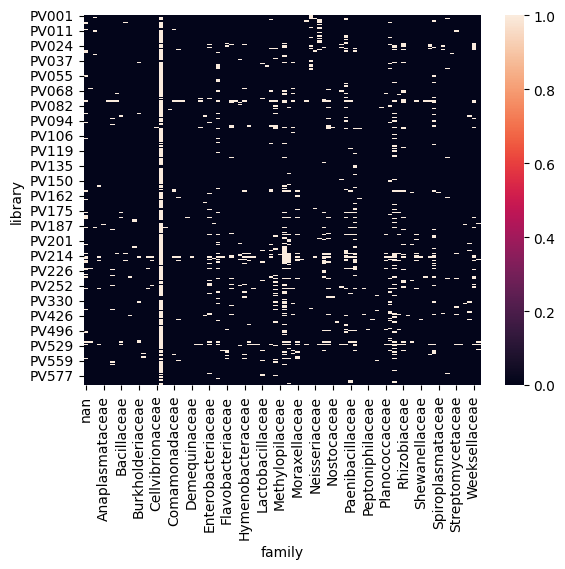

In [52]:
sns.heatmap(motus_pvt_collection['family'])

<Axes: xlabel='class', ylabel='library'>

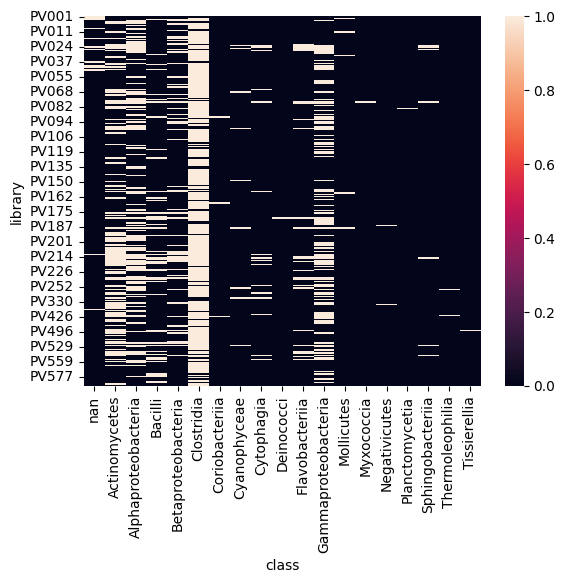

In [53]:
sns.heatmap(motus_pvt_collection['class'])

<Axes: xlabel='phylum', ylabel='library'>

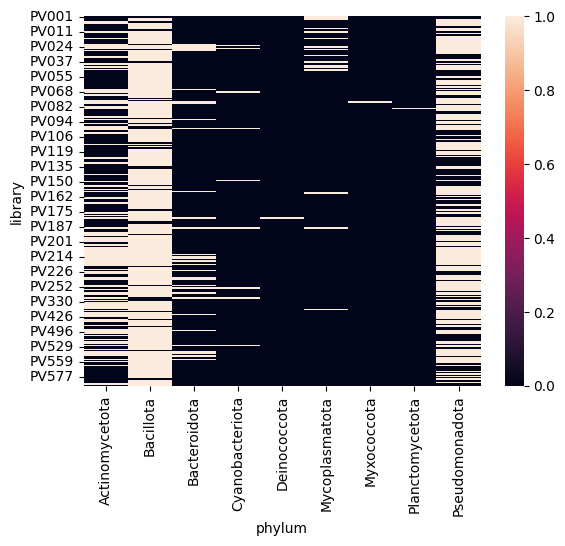

In [54]:
sns.heatmap(motus_pvt_collection['phylum'])

Let's save all of them, jic. 

In [55]:
for key, item in motus_pvt_collection.items():

    item.to_csv(f"../results/2025-06-13.sprint/intdata.bacteria-species-pivot.rank_{key}.csv", sep=';')

The species don't work because the dataset is too sparse. Let's remove all taxids that have less than 8 items.

In [56]:
motus_df_pvt = motus_df.drop_duplicates(['library', 'species'], keep='first').pivot(index='library', columns='species', values='foo').fillna(0).astype(int)
motus_df_pvt[motus_df.value_counts('species').reset_index().query('count > 8')['species'].to_list()].to_csv("../results/2025-06-13.sprint/intdata.bacteria-species-taxid8.csv", sep=";")

In [57]:
motus_df.value_counts('taxid').reset_index()

,taxid,count
0,59620,251
1,28447,28
2,1736282,26
3,1828,22
4,1747,21
...,...,...
514,866564,1
515,861266,1
516,758825,1
517,67386,1


In [58]:
motus_df_pvt_habitat = motus_df.drop_duplicates('library').pivot(index='library', values='foo', columns='Habitat').fillna(0).reset_index()
motus_df_pvt_location = motus_df.drop_duplicates('library').pivot(index='library', values='foo', columns='Location').fillna(0).reset_index()
motus_df_pvt_host = motus_df.drop_duplicates('library').pivot(index='library', values='foo', columns='Host_taxon').fillna(0).reset_index()

In [59]:
motus_df_pvt_habitat

Habitat,library,Crop,Edge,Oak,Wasteland
0,PV001,1.0,0.0,0.0,0.0
1,PV002,1.0,0.0,0.0,0.0
2,PV003,1.0,0.0,0.0,0.0
3,PV003bgi,1.0,0.0,0.0,0.0
4,PV004bgi,1.0,0.0,0.0,0.0
...,...,...,...,...,...
291,PV584,0.0,0.0,0.0,1.0
292,PV586,1.0,0.0,0.0,0.0
293,PV587,1.0,0.0,0.0,0.0
294,PV588,1.0,0.0,0.0,0.0


In [60]:
covariates = pd.merge(pd.merge(motus_df_pvt_habitat, motus_df_pvt_location, on='library'), motus_df_pvt_host, on='library')
covariates

,library,Crop,Edge,Oak,Wasteland,Ambite,Aranjuez,Mondéjar,San Martín de la Vega,Tielmes,...,Thapsia villosa,Thymus vulgaris,Torilis nodosa,Tragopogon sp,Trifolium campestre,Trifolium tomentosum,Verbascum sinuatum,Vicia sp,Xanthium strumarium,Zea mays
0,PV001,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,PV002,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,PV003,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,PV003bgi,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,PV004bgi,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,PV584,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
292,PV586,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
293,PV587,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
294,PV588,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
motus_df_pvt = motus_df.drop_duplicates(['library', 'species'], keep='first').pivot(index='library', columns='species', values='foo').fillna(0).astype(int)
motus_df_pvt = motus_df_pvt[motus_df.value_counts('species').reset_index().query('count > 8')['species'].to_list()]
motus_df_pvt

species,uncultured Clostridium sp.,Clavibacter michiganensis,Frigoribacterium sp. Leaf164,Rhodococcoides fascians,Pseudomonas lutea,Cutibacterium acnes,Paracoccus sp. 228,Methylobacterium sp. Leaf125,Exiguobacterium undae,Chryseobacterium sp. Leaf201,...,Agrobacterium tumefaciens,Kocuria polaris,Arthrobacter sp. Leaf234,Escherichia coli,Arthrobacter sp. RIT-PI-e,Massilia timonae,Pseudomonas sp. Leaf127,Sphingomonas sp. Leaf20,Bradyrhizobium elkanii,Burkholderiales bacterium RIFCSPLOWO2_12_FULL_65_40
library,,,,,,,,,,,,,,,,,,,,,
PV001,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
PV002,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
PV003,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
PV003bgi,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
PV004bgi,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PV584,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
PV586,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
PV587,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [38]:
pd.merge(motus_df_pvt.reset_index(), covariates, on='library').set_index('library').to_csv("../results/2025-06-13.sprint/intdata.bacteria8-covariates.csv", sep=';')

In [6]:
import networkx as nx
import math

In [7]:
abs(-1)

1

In [5]:
G = nx.read_graphml("../results/2025-06-13.sprint/intdata.rmf-species-8.graphml")


In [8]:
for _, _, edge_data in G.edges(data=True):
    edge_data['w'] = edge_data['weight']
    edge_data['weight'] = abs(edge_data['weight'])

In [10]:
nx.write_gml(G, "../results/2025-06-13.sprint/intdata.rmf-species-8.fixed.gml")

In [ ]:
def convert_graph(path_in, path_out):
    G = nx.read_graphml(path_in)
    for _, _, edge_data in G.edges(data=True):
        edge_data['w'] = edge_data['weight']
        edge_data['weight'] = abs(edge_data['weight'])
    nx.write_gml(G, path_out)

In [40]:
convert_graph("../results/2025-06-13.sprint/intdata.species8-covariates.graphml", "../results/2025-06-13.sprint/intdata.species8-covariates.gml")

## Virus - Bacteria

In [2]:
from rdflib import Graph

In [3]:
sites = Graph()
sites.parse(open("../results/2025-06-17.mulvirisk-model2/sites.ttl"))

libraries = Graph()
libraries.parse(open("../results/2025-06-17.mulvirisk-model2/libraries.ttl"))

hosts = Graph()
hosts.parse(open("../results/2025-06-17.mulvirisk-model2/host.ttl"))

virus = Graph()
virus.parse(open("../results/2025-06-17.mulvirisk-model2/virus.ttl"))

bacteria = Graph()
bacteria.parse(open("../results/2025-06-17.mulvirisk-model2/bacteria.ttl"))

G = sites + libraries + hosts + virus + bacteria

In [16]:
res = G.query(
    """
    PREFIX mvrtaxon: <http://localhost:8000/taxon/>
    PREFIX mvrlib: <http://localhost:8000/library/>
    PREFIX mvront: <http://localhost:8000/ont/>
    PREFIX wlo: <http://purl.org/ontology/wo/>
    PREFIX emi: <https://purl.org/emi#>
    
    SELECT ?site ?lib ?hit ?type ?name ?host
    WHERE {
        ?site a mvront:Site .
        ?lib mvront:Sampled_from ?site .
        ?lib mvront:Reported ?organism .
        ?organism emi:inTaxon ?hit .
        ?hit mvront:OrganismKingdom ?type .
        ?hit emi:scientificName ?name .
        ?lib mvront:Obtained_from ?host 
    }
    """
)
pd.DataFrame(res, columns=list(res.vars))

,site,lib,hit,type,name,host
0,http://localhost:8000/site/H3,http://localhost:8000/library/PV498,http://localhost:8000/taxon/000000000215,Virus,Pepper vein yellows virus,http://localhost:8000/host/000000000020
1,http://localhost:8000/site/H3,http://localhost:8000/library/PV498,http://localhost:8000/taxon/000000000223,Virus,Cowpea polerovirus 1,http://localhost:8000/host/000000000020
2,http://localhost:8000/site/H3,http://localhost:8000/library/PV498,http://localhost:8000/taxon/000000000200,Virus,Beet western yellows virus,http://localhost:8000/host/000000000020
3,http://localhost:8000/site/H3,http://localhost:8000/library/PV498,http://localhost:8000/taxon/000000000216,Virus,Suakwa aphid-borne yellows virus,http://localhost:8000/host/000000000020
4,http://localhost:8000/site/H3,http://localhost:8000/library/PV498,http://localhost:8000/taxon/000000000197,Virus,Beet chlorosis virus,http://localhost:8000/host/000000000020
...,...,...,...,...,...,...
3076,http://localhost:8000/site/Q2,http://localhost:8000/library/PV113,http://localhost:8000/taxon/000000000291,Bacteria,uncultured Clostridium sp.,http://localhost:8000/host/000000000026
3077,http://localhost:8000/site/Q2,http://localhost:8000/library/PV111,http://localhost:8000/taxon/000000000266,Virus,Tobacco mild green mosaic virus,http://localhost:8000/host/000000000005
3078,http://localhost:8000/site/Q2,http://localhost:8000/library/PV111,http://localhost:8000/taxon/000000000147,Virus,Cucumber mosaic virus RNA 3,http://localhost:8000/host/000000000005
3079,http://localhost:8000/site/Q2,http://localhost:8000/library/PV111,http://localhost:8000/taxon/000000000236,Virus,Watermelon mosaic virus,http://localhost:8000/host/000000000005


In [26]:
pd.DataFrame(res, columns=list(map(lambda x: str(x), res.vars))).columns[0]

'site'

In [29]:
virus_bacteria = pd.DataFrame(res, columns=list(map(lambda x: str(x), res.vars)))
virus_bacteria['site'] = virus_bacteria['site'].apply(lambda x: x.split("/")[-1])
virus_bacteria['lib'] = virus_bacteria['lib'].apply(lambda x: x.split("/")[-1])
virus_bacteria['hit'] = virus_bacteria['hit'].apply(lambda x: x.split("/")[-1])
virus_bacteria['host'] = virus_bacteria['host'].apply(lambda x: x.split("/")[-1])
virus_bacteria

,site,lib,hit,type,name,host
0,H3,PV498,000000000215,Virus,Pepper vein yellows virus,000000000020
1,H3,PV498,000000000223,Virus,Cowpea polerovirus 1,000000000020
2,H3,PV498,000000000200,Virus,Beet western yellows virus,000000000020
3,H3,PV498,000000000216,Virus,Suakwa aphid-borne yellows virus,000000000020
4,H3,PV498,000000000197,Virus,Beet chlorosis virus,000000000020
...,...,...,...,...,...,...
3076,Q2,PV113,000000000291,Bacteria,uncultured Clostridium sp.,000000000026
3077,Q2,PV111,000000000266,Virus,Tobacco mild green mosaic virus,000000000005
3078,Q2,PV111,000000000147,Virus,Cucumber mosaic virus RNA 3,000000000005
3079,Q2,PV111,000000000236,Virus,Watermelon mosaic virus,000000000005


In [32]:
names = virus_bacteria.value_counts('name').reset_index().query('count > 8')['name'].to_list()

In [39]:
virus_bacteria['foo'] = 1
virus_bacteria_pvt = virus_bacteria.drop_duplicates(['lib', 'site', 'name'], keep='first').pivot(index=['lib', 'site'], columns='name', values='foo').fillna(0).astype(int)
virus_bacteria_pvt = virus_bacteria_pvt[names]
virus_bacteria_pvt

,name,uncultured Clostridium sp.,Cucumber mosaic virus RNA 3,Pelargonium zonate spot virus RNA 3,Rubus chlorotic mottle virus,Tobacco mild green mosaic virus,Tobacco mosaic virus,Watermelon mosaic virus,Tomato aspermy virus RNA 3,Pepper mild mottle virus,Parietaria mottle virus RNA 3,...,Soybean mosaic virus,Tomato brown rugose fruit virus,,Sweet potato chlorotic stunt virus RNA 1,Plum pox virus,Sphingomonas sp. Leaf20,Bradyrhizobium elkanii,Burkholderiales bacterium RIFCSPLOWO2_12_FULL_65_40,Cucurbit aphid-borne yellows virus,Pseudomonas sp. Leaf127
lib,site,,,,,,,,,,,,,,,,,,,,,
PV001,M1,0,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
PV002,M1,1,1,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
PV003,M1,1,1,0,0,0,0,1,1,0,0,...,1,0,0,0,0,0,0,0,0,0
PV003bgi,M1,1,1,0,0,0,0,1,0,1,0,...,1,0,0,0,0,0,1,0,0,0
PV004bgi,M1,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PV586,H1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
PV587,H1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
PV588,H1,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<Axes: xlabel='name', ylabel='lib-site'>

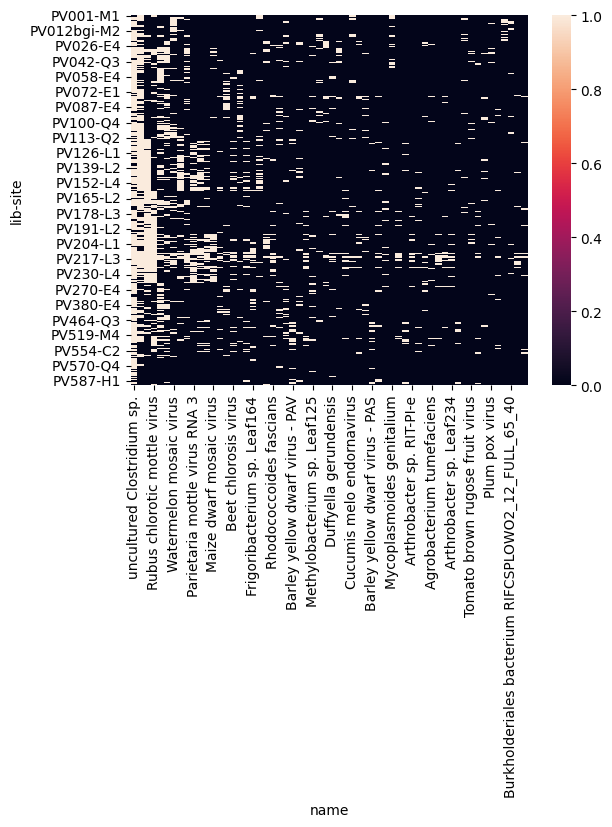

In [ ]:
sns.heatmap(virus_bacteria_pvt)

In [42]:
virus_bacteria_pvt.to_csv("../results/2025-06-13.sprint/intdata.virus-bacteria.mrf-ready.csv", sep=';', index=None)

In [64]:
pd.merge(virus_bacteria_pvt, covariates, left_on='lib', right_on='library').drop(columns='library').to_csv(
    "../results/2025-06-13.sprint/intdata.virus-bacteria.crf-ready.csv", sep=';', index=None
)

In [67]:
import networkx as nx 

In [68]:
convert_graph(
    "../results/2025-06-13.sprint/intdata.virus-bacteria-CRF-graph.graphml", 
    "../results/2025-06-13.sprint/intdata.virus-bacteria-CRF-graph.gmml", 
)